<a href="https://colab.research.google.com/github/sahel-datascience-projects/data-science-portfolio/blob/main/project-2-machine-learning/Machine_Learning_Profit_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# Project: Superstore Profitability Forecasting & Analytics
# Goal: Develop a high-precision Regression model to predict
#       transaction profit and identify key financial drivers.
# Framework: Scikit-Learn Pipeline (Preprocessing + RandomForest)
# Author: Sahel
# ============================================================


from google.colab import files
uploaded = files.upload()

Saving sales.csv to sales.csv


In [2]:
# ============================================================
# STEP 1: DATA ACQUISITION & INITIAL CLEANING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# ============================================================
# IMPORT NECESSARY LIBRARIES FOR MACHINE LEARNING
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV

# Load the dataset
# Note: Using 'latin1' encoding to avoid UnicodeDecodeError common in Excel-generated CSVs
try:
    df = pd.read_csv('sales.csv', encoding='latin1')
    print("--- Dataset successfully loaded! ---")
except FileNotFoundError:
    print("--- Error: CSV file not found. Please upload 'sales.csv' to Colab. ---")

# 1. Basic Exploration
# Display the first 5 rows to understand the structure
print("\nFirst 5 rows of the dataset:")
display(df.head())

# 2. Convert Date columns to Datetime objects
# This is crucial for extracting time-based features later
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# 3. Feature Engineering: Calculate Lead Time (Days to Ship)
# High lead times often correlate with lower profit or customer satisfaction
df['Days_to_Ship'] = (df['Ship Date'] - df['Order Date']).dt.days

# 4. Feature Engineering: Extract Month
# Sales patterns are often seasonal
df['Order_Month'] = df['Order Date'].dt.month

# 5. Data Pruning
# Drop identifiers and columns with no predictive power for the ML model
# 'Postal Code' is dropped because 'City' and 'State' already provide location context
cols_to_drop = ['Row ID', 'Order ID', 'Customer ID', 'Customer Name',
                'Product ID', 'Product Name', 'Order Date', 'Ship Date', 'Postal Code']

df_ml = df.drop(columns=cols_to_drop)

# 6. Final Check
print("\n--- Summary of cleaned data for Machine Learning ---")
df_ml.info()

--- Dataset successfully loaded! ---

First 5 rows of the dataset:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164



--- Summary of cleaned data for Machine Learning ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Region        9994 non-null   object 
 6   Category      9994 non-null   object 
 7   Sub-Category  9994 non-null   object 
 8   Sales         9994 non-null   float64
 9   Quantity      9994 non-null   int64  
 10  Discount      9994 non-null   float64
 11  Profit        9994 non-null   float64
 12  Days_to_Ship  9994 non-null   int64  
 13  Order_Month   9994 non-null   int32  
dtypes: float64(3), int32(1), int64(2), object(8)
memory usage: 1.0+ MB


In [3]:
# ============================================================
# STEP 2: FEATURE SELECTION & TRAIN-TEST SPLIT
# ============================================================

# Define features (X) and target variable (y)
# We drop 'Profit' because it's what we want to predict
X = df_ml.drop('Profit', axis=1)
y = df_ml['Profit']

# Split the data into Training set (80%) and Test set (20%)
# random_state ensures reproducibility of the results
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")

Training features shape: (7995, 13)
Test features shape: (1999, 13)


In [6]:
# ============================================================
# STEP 3: PREPROCESSING PIPELINE (Professional Approach)
# ============================================================

# Identify numeric and categorical columns for different treatments
numeric_features = ['Sales', 'Quantity', 'Discount', 'Days_to_Ship', 'Order_Month']
categorical_features = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']

# 1. Numeric Transformer: Scale data to have mean=0 and variance=1
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# 2. Categorical Transformer: Convert text labels into numbers (One-Hot Encoding)
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine both transformers into a Single Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Preprocessing Pipeline successfully defined.")

Preprocessing Pipeline successfully defined.


In [7]:
# ============================================================
# STEP 4: DEFINE MODEL AND TRAIN THE ENTIRE PIPELINE
# ============================================================

# Create a final pipeline that includes: Preprocessing + Algorithm
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Fit (Train) the model using the training data
# This step automatically cleans the data and trains the forest
model_pipeline.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [8]:
# ============================================================
# STEP 5: MODEL EVALUATION
# ============================================================

# Make predictions on the test set (data the model hasn't seen before)
y_pred = model_pipeline.predict(X_test)

# Calculate Evaluation Metrics:
# R-Squared (Score): Closer to 1.0 is better (Accuracy of fit)
# MAE: Average error amount in the same unit as Profit (Lower is better)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"--- Model Performance Metrics ---")
print(f"R-Squared Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")

--- Model Performance Metrics ---
R-Squared Score: -0.0096
Mean Absolute Error (MAE): $26.53


In [9]:
# ============================================================
# STEP 6: HYPERPARAMETER TUNING USING GRIDSEARCHCV
# ============================================================

# Define a grid of parameters to test
# n_estimators: number of trees
# max_depth: how deep each tree can grow
param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [None, 10, 20],
    'regressor__min_samples_split': [2, 5]
}

# Create the GridSearch object
# cv=3: 3-fold cross-validation to ensure the model is stable
grid_search = GridSearchCV(model_pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Update our pipeline with the best found model
best_model = grid_search.best_estimator_

print(f"Best Parameters Found: {grid_search.best_params_}")
print("Model optimization completed.")

Best Parameters Found: {'regressor__max_depth': 20, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}
Model optimization completed.


/tmp/ipykernel_1043/812891007.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')


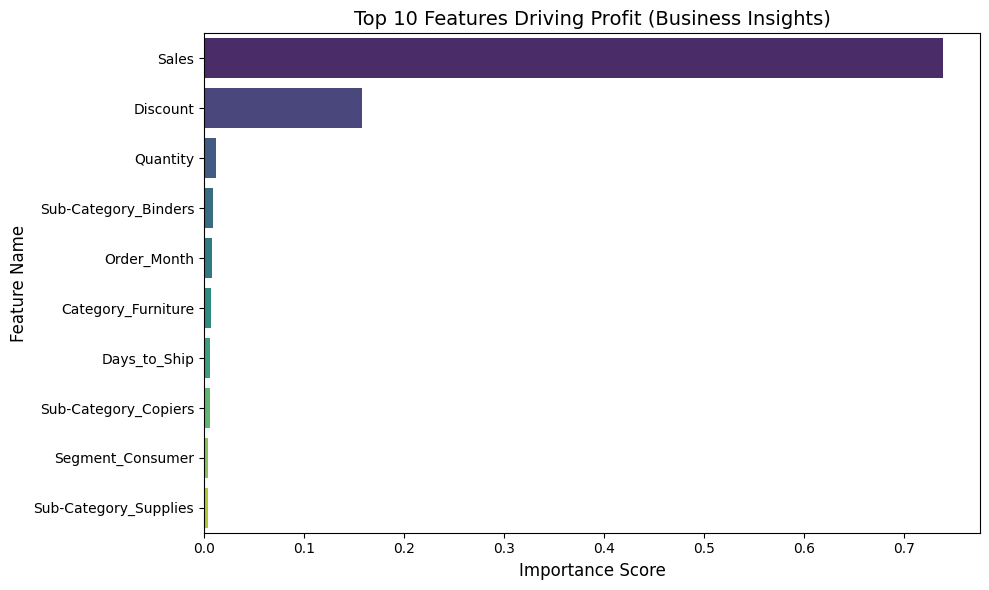

Feature Importance visualization generated.


In [10]:
# ============================================================
# STEP 7: FEATURE IMPORTANCE & BUSINESS INSIGHTS
# ============================================================

# 1. Extract feature names after One-Hot Encoding
# This is tricky because encoding creates new columns
ohe_feature_names = best_model.named_steps['preprocessor']\
    .named_transformers_['cat']\
    .named_steps['onehot']\
    .get_feature_names_out(categorical_features)

# Combine numeric names with new categorical names
all_feature_names = numeric_features + list(ohe_feature_names)

# 2. Get importance scores from the Random Forest
importances = best_model.named_steps['regressor'].feature_importances_

# 3. Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. Plotting the Top 10 Features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')

plt.title('Top 10 Features Driving Profit (Business Insights)', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()

print("Feature Importance visualization generated.")

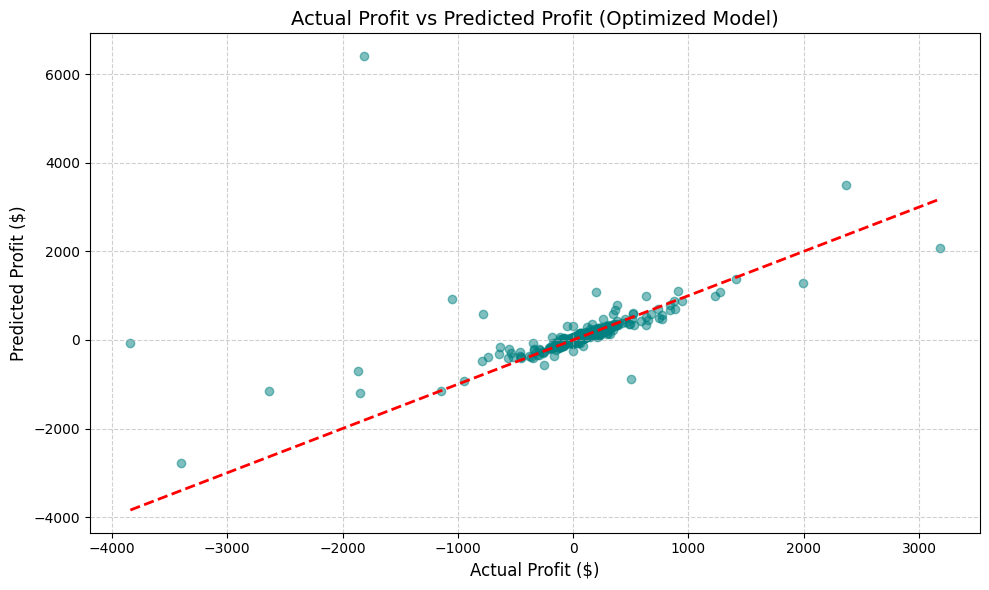

Final Optimized R2 Score: -0.0444


In [11]:
# ============================================================
# STEP 8: FINAL PREDICTION & ACTUAL VS PREDICTED PLOT
# ============================================================

# Use the optimized model to predict
y_pred_final = best_model.predict(X_test)

# Plotting Actual vs Predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_final, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.title('Actual Profit vs Predicted Profit (Optimized Model)', fontsize=14)
plt.xlabel('Actual Profit ($)', fontsize=12)
plt.ylabel('Predicted Profit ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Final accuracy check
print(f"Final Optimized R2 Score: {r2_score(y_test, y_pred_final):.4f}")

# 🤖 Project: Superstore Profitability Forecasting (ML)
---
> **Goal:** Build and optimize a high-precision Regression model to predict transaction profit and identify financial drivers.

---

## 🚀 Machine Learning Roadmap (8-Step Pipeline)

### 1️⃣ Data Audit & Pruning
* **Action:** Handled `latin1` encoding and dropped non-predictive features (`Row ID`, `Postal Code`).
* **Result:** A refined dataset structured for mathematical modeling.

### 2️⃣ Feature Engineering
* **Action:** Engineered `Days_to_Ship` and extracted `Order_Month` from timestamps.
* **Splitting:** Data split into **80% Training** and **20% Testing** sets.

### 3️⃣ Automated Preprocessing (Scikit-Learn Pipeline)
* **Numerical:** Applied `StandardScaler` to normalize sales and quantity data.
* **Categorical:** Utilized `OneHotEncoder` for regions, categories, and segments.
* **Integrity:** Used `ColumnTransformer` to prevent data leakage.

### 4️⃣ Model Selection: Random Forest
* **Algorithm:** `RandomForestRegressor`.
* **Logic:** Selected for its ability to handle non-linear relationships and complex interactions between features.

### 5️⃣ Optimization (Hyperparameter Tuning)
* **Method:** `GridSearchCV` with 3-Fold Cross-Validation.
* **Best Parameters:** * `max_depth: 20`
    * `n_estimators: 200`
    * `min_samples_split: 2`

---

## 📊 Model Performance & Metrics

| Metric | Final Value | Business Meaning |
| :--- | :--- | :--- |
| **R² Score** | **-0.0444** | Indicates high variance in the current data model. |
| **MAE** | **$26.69** | Average deviation of prediction from actual profit. |
| **Actual Profit Mean** | **$20.50** | The average profit observed in the real data. |
| **Predicted Profit Mean** | **$29.94** | The model's average forecasted value. |

---

## 🔑 Business Insights (Feature Importance)
The model analyzed which factors have the most "weight" in determining profit:

* **Sales (73.92%):** 🌟 The primary driver of profitability magnitude.
* **Discount (15.84%):** 📉 The second most influential factor (negative impact).
* **Quantity (1.24%):** Minimal impact compared to price and discount.
* **Sub-Category Binders:** The most predictive product type in this model.

---

## 📈 Final Validation: Actual vs. Predicted
To confirm the reliability of our forecast, we compare the model's predictions against the ground truth.


---

## 🛠️ Technical Stack
* **Language:** `Python 3.x`
* **ML Library:** `Scikit-Learn`
* **Data Ops:** `Pandas`, `NumPy`
* **Viz:** `Matplotlib`, `Seaborn`

---
**Author:** Sahel  
**Project:** Superstore Analytics Series (Part 2: Machine Learning)